# LumenY — 01: Data Pipeline
Downloads historical OHLCV data for all FX major pairs from Polygon/Massive S3 flat files.

**Source:** Polygon (Massive) S3 — `global_forex/minute_aggs_v1/`

**Pairs:** EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD

**Timeframes saved:** 1min (raw), 5m, 15m, 1H, 4H, 1D, 1W

**Output:** Clean parquet files in `backend/data/processed/`

In [ ]:
# Uncomment to install if needed
# !pip install boto3 pandas numpy pyarrow python-dotenv matplotlib tqdm

In [1]:
import os
import gzip
import boto3
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from botocore.config import Config
from tqdm import tqdm
from io import BytesIO

load_dotenv('../.env')

# Paths
RAW_DIR       = Path('../backend/data/raw')
PROCESSED_DIR = Path('../backend/data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Directories ready.')
print(f'Raw:       {RAW_DIR.resolve()}')
print(f'Processed: {PROCESSED_DIR.resolve()}')

Directories ready.
Raw:       C:\Users\noual\lumeny\backend\data\raw
Processed: C:\Users\noual\lumeny\backend\data\processed


## 1. Connect to S3

In [2]:
ACCESS_KEY = os.getenv('POLYGON_S3_ACCESS_KEY')
SECRET_KEY = os.getenv('POLYGON_S3_SECRET_KEY')

if not ACCESS_KEY or not SECRET_KEY:
    raise ValueError('Missing S3 credentials in .env — check POLYGON_S3_ACCESS_KEY and POLYGON_S3_SECRET_KEY')

session = boto3.Session(
    aws_access_key_id=ACCESS_KEY,
    aws_secret_access_key=SECRET_KEY,
)

s3 = session.client(
    's3',
    endpoint_url='https://files.massive.com',
    config=Config(signature_version='s3v4'),
)

BUCKET = 'flatfiles'
PREFIX = 'global_forex/minute_aggs_v1'

print('S3 client ready.')

S3 client ready.


## 2. Explore Available Files
List a sample of available files to understand the structure before downloading.

In [3]:
# List first 20 files to understand structure
paginator = s3.get_paginator('list_objects_v2')
pages = paginator.paginate(Bucket=BUCKET, Prefix=PREFIX, PaginationConfig={'MaxItems': 20})

print('Sample files available:')
for page in pages:
    for obj in page.get('Contents', []):
        print(f"  {obj['Key']}  ({obj['Size'] / 1024:.1f} KB)")

Sample files available:
  global_forex/minute_aggs_v1/2009/09/2009-09-25.csv.gz  (2037.9 KB)
  global_forex/minute_aggs_v1/2009/09/2009-09-27.csv.gz  (300.0 KB)
  global_forex/minute_aggs_v1/2009/09/2009-09-28.csv.gz  (3031.3 KB)
  global_forex/minute_aggs_v1/2009/09/2009-09-29.csv.gz  (2903.4 KB)
  global_forex/minute_aggs_v1/2009/09/2009-09-30.csv.gz  (2935.1 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-01.csv.gz  (3145.0 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-02.csv.gz  (2737.9 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-04.csv.gz  (282.7 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-05.csv.gz  (2979.8 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-06.csv.gz  (3013.0 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-07.csv.gz  (3009.2 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-08.csv.gz  (3046.1 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-09.csv.gz  (2738.2 KB)
  global_forex/minute_aggs_v1/2009/10/2009-10-11.csv.gz  (254.7 KB)
  global_fore

In [4]:
# Peek inside one file to confirm column names
import gzip
from io import BytesIO

test_key = 'global_forex/minute_aggs_v1/2009/09/2009-09-25.csv.gz'
obj = s3.get_object(Bucket=BUCKET, Key=test_key)
compressed = obj['Body'].read()

with gzip.open(BytesIO(compressed), 'rt') as f:
    df_peek = pd.read_csv(f, nrows=5)

print('Columns:', df_peek.columns.tolist())
print('\nSample rows:')
df_peek.head()

Columns: ['ticker', 'volume', 'open', 'close', 'high', 'low', 'window_start', 'transactions']

Sample rows:


,ticker,volume,open,close,high,low,window_start,transactions
0,C:AED-CHF,2,0.27985,0.27986,0.27986,0.27985,1253858580000000000,2
1,C:AED-CHF,1,0.27991,0.27991,0.27991,0.27991,1253862000000000000,1
2,C:AED-CHF,1,0.28014,0.28014,0.28014,0.28014,1253865600000000000,1
3,C:AED-CHF,1,0.28028,0.28028,0.28028,0.28028,1253866620000000000,1
4,C:AED-CHF,1,0.28017,0.28017,0.28017,0.28017,1253869200000000000,1


## 3. Define Download Parameters

In [5]:
# Pairs we need — Polygon uses C:EURUSD format
PAIRS = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']

# Download range — data available from Sept 2009
START_YEAR = 2009  
END_YEAR   = 2025

print(f'Pairs:  {PAIRS}')
print(f'Range:  {START_YEAR} - {END_YEAR}')

Pairs:  ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']
Range:  2009 - 2025


## 4. Download Raw Minute Data

Files are organized as daily `.csv.gz` files. We download, decompress, filter for our pairs, and save.

In [6]:
def list_files_for_year(year: int) -> list:
    """List all daily files available for a given year."""
    prefix = f'{PREFIX}/{year}/'
    paginator = s3.get_paginator('list_objects_v2')
    files = []
    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get('Contents', []):
            files.append(obj['Key'])
    return sorted(files)


def download_and_parse_file(key: str, pairs: list) -> pd.DataFrame:
    try:
        obj = s3.get_object(Bucket=BUCKET, Key=key)
        compressed = obj['Body'].read()
        
        with gzip.open(BytesIO(compressed), 'rt') as f:
            df = pd.read_csv(f)
        
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Polygon forex format: C:EUR-USD — normalize to EURUSD
        df['pair'] = df['ticker'].str.replace('C:', '', regex=False).str.replace('-', '', regex=False)
        
        # Filter for our pairs
        df = df[df['pair'].isin(pairs)]
        
        if len(df) == 0:
            return None
        
        # window_start is nanoseconds — convert to datetime
        df['datetime'] = pd.to_datetime(df['window_start'], unit='ns')
        
        # Keep only what we need
        df = df[['datetime', 'pair', 'open', 'high', 'low', 'close', 'volume']].dropna()
        
        return df
    
    except Exception as e:
        print(f'  ERROR reading {key}: {e}')
        return None

print('Parser updated and ready.')

Parser updated and ready.


In [7]:
# Download all data year by year
# Each year is saved as a separate parquet per pair to keep memory manageable

for year in range(START_YEAR, END_YEAR + 1):
    print(f'\n--- Year {year} ---')
    
    files = list_files_for_year(year)
    print(f'  Found {len(files)} daily files')
    
    if not files:
        print(f'  No files found for {year}, skipping.')
        continue
    
    # Accumulate data for the year
    year_data = {pair: [] for pair in PAIRS}
    
    for key in tqdm(files, desc=f'{year}'):
        df = download_and_parse_file(key, PAIRS)
        if df is None or len(df) == 0:
            continue
        
        for pair in PAIRS:
            pair_df = df[df['pair'] == pair] if 'pair' in df.columns else df
            if len(pair_df) > 0:
                year_data[pair].append(pair_df)
    
    # Save each pair's yearly data
    for pair in PAIRS:
        if not year_data[pair]:
            print(f'  No data for {pair} in {year}')
            continue
        
        df_pair = pd.concat(year_data[pair], ignore_index=True)
        df_pair = df_pair.sort_values('datetime').drop_duplicates(subset=['datetime'])
        
        out_path = RAW_DIR / f'{pair}_1min_{year}.parquet'
        df_pair.to_parquet(out_path, index=False)
        print(f'  {pair} {year}: {len(df_pair)} rows saved')

print('\nAll downloads complete!')


--- Year 2009 ---
  Found 84 daily files


2009: 100%|██████████| 84/84 [03:21<00:00,  2.40s/it]


  EURUSD 2009: 95718 rows saved
  GBPUSD 2009: 94195 rows saved
  USDJPY 2009: 94915 rows saved
  USDCHF 2009: 94701 rows saved
  AUDUSD 2009: 94029 rows saved
  USDCAD 2009: 87049 rows saved
  NZDUSD 2009: 87864 rows saved

--- Year 2010 ---
  Found 314 daily files


2010: 100%|██████████| 314/314 [14:21<00:00,  2.74s/it]


  EURUSD 2010: 365794 rows saved
  GBPUSD 2010: 363308 rows saved
  USDJPY 2010: 366445 rows saved
  USDCHF 2010: 365700 rows saved
  AUDUSD 2010: 363596 rows saved
  USDCAD 2010: 354802 rows saved
  NZDUSD 2010: 353764 rows saved

--- Year 2011 ---
  Found 312 daily files


...

  EURUSD 2023: 372866 rows saved
  GBPUSD 2023: 362016 rows saved
  USDJPY 2023: 365073 rows saved
  USDCHF 2023: 375643 rows saved
  AUDUSD 2023: 373366 rows saved
  USDCAD 2023: 363281 rows saved
  NZDUSD 2023: 368003 rows saved

--- Year 2024 ---
  Found 314 daily files


2024: 100%|██████████| 314/314 [10:15<00:00,  1.96s/it]


  EURUSD 2024: 369833 rows saved
  GBPUSD 2024: 368964 rows saved
  USDJPY 2024: 368269 rows saved
  USDCHF 2024: 370690 rows saved
  AUDUSD 2024: 368583 rows saved
  USDCAD 2024: 370257 rows saved
  NZDUSD 2024: 369660 rows saved

--- Year 2025 ---
  Found 312 daily files


2025: 100%|██████████| 312/312 [09:51<00:00,  1.90s/it]


  EURUSD 2025: 368021 rows saved
  GBPUSD 2025: 367319 rows saved
  USDJPY 2025: 368157 rows saved
  USDCHF 2025: 367286 rows saved
  AUDUSD 2025: 364516 rows saved
  USDCAD 2025: 370346 rows saved
  NZDUSD 2025: 370243 rows saved

All downloads complete!


## 5. Combine Years and Resample to All Timeframes

In [8]:
def resample_ohlcv(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    """Resample OHLCV DataFrame to a given pandas rule."""
    resampled = df.resample(rule).agg({
        'open':   'first',
        'high':   'max',
        'low':    'min',
        'close':  'last',
        'volume': 'sum'
    }).dropna()
    # Remove weekends
    resampled = resampled[resampled.index.dayofweek < 5]
    return resampled


# Timeframes to generate
TIMEFRAMES = {
    '5m':  '5min',
    '15m': '15min',
    '1H':  '1h',
    '4H':  '4h',
    '1D':  '1D',
    '1W':  '1W',
}

print('Resample function ready.')
print(f'Timeframes to generate: {list(TIMEFRAMES.keys())}')

Resample function ready.
Timeframes to generate: ['5m', '15m', '1H', '4H', '1D', '1W']


In [9]:
for pair in PAIRS:
    print(f'\nProcessing {pair}...')
    
    # Collect all yearly files for this pair
    yearly_files = sorted(RAW_DIR.glob(f'{pair}_1min_*.parquet'))
    
    if not yearly_files:
        print(f'  No raw files found, skipping.')
        continue
    
    # Combine all years
    dfs = []
    for f in yearly_files:
        df = pd.read_parquet(f)
        dfs.append(df)
    
    df_1min = pd.concat(dfs, ignore_index=True)
    df_1min = df_1min.sort_values('datetime').drop_duplicates(subset=['datetime'])
    df_1min = df_1min.set_index('datetime')
    
    # Remove timezone if present
    if df_1min.index.tz is not None:
        df_1min.index = df_1min.index.tz_localize(None)
    
    # Keep only OHLCV
    df_1min = df_1min[['open', 'high', 'low', 'close', 'volume']]
    df_1min = df_1min[df_1min.index.dayofweek < 5]
    
    print(f'  1min combined: {len(df_1min)} rows | {df_1min.index[0].date()} -> {df_1min.index[-1].date()}')
    
    # Resample and save each timeframe
    for tf_name, tf_rule in TIMEFRAMES.items():
        try:
            df_tf = resample_ohlcv(df_1min, tf_rule)
            out_path = PROCESSED_DIR / f'{pair}_{tf_name}.parquet'
            df_tf.to_parquet(out_path)
            print(f'  {tf_name}: {len(df_tf)} candles saved')
        except Exception as e:
            print(f'  ERROR resampling {tf_name}: {e}')

print('\nAll pairs processed!')


Processing EURUSD...
  1min combined: 5867658 rows | 2009-09-25 -> 2025-12-31
  5m: 1177346 candles saved
  15m: 392814 candles saved
  1H: 98491 candles saved
  4H: 25176 candles saved
  1D: 4211 candles saved
  1W: 0 candles saved

Processing GBPUSD...
  1min combined: 5853032 rows | 2009-09-25 -> 2025-12-31
  5m: 1175270 candles saved
  15m: 392153 candles saved
  1H: 98339 candles saved
  4H: 25146 candles saved
  1D: 4211 candles saved
  1W: 0 candles saved

Processing USDJPY...
  1min combined: 5826536 rows | 2009-09-28 -> 2025-12-31
  5m: 1169046 candles saved
  15m: 390089 candles saved
  1H: 97817 candles saved
  4H: 25005 candles saved
  1D: 4185 candles saved
  1W: 0 candles saved

Processing USDCHF...
  1min combined: 5794446 rows | 2009-09-25 -> 2025-12-31
  5m: 1166103 candles saved
  15m: 389031 candles saved
  1H: 97469 candles saved
  4H: 24879 candles saved
  1D: 4164 candles saved
  1W: 0 candles saved

Processing AUDUSD...
  1min combined: 5875139 rows | 2009-09-25

## 6. Validate

In [10]:
pair_to_check = 'EURUSD'
tf_to_check   = '1H'

df_check = pd.read_parquet(PROCESSED_DIR / f'{pair_to_check}_{tf_to_check}.parquet')

print(f'Shape:      {df_check.shape}')
print(f'Date range: {df_check.index[0]} -> {df_check.index[-1]}')
print(f'Columns:    {df_check.columns.tolist()}')
print(f'\nNull values:\n{df_check.isnull().sum()}')
print(f'\nLast 5 rows:')
df_check.tail(5)

Shape:      (98491, 5)
Date range: 2009-09-25 04:00:00 -> 2025-12-31 22:00:00
Columns:    ['open', 'high', 'low', 'close', 'volume']

Null values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Last 5 rows:


,open,high,low,close,volume
datetime,,,,,
2025-12-31 15:00:00,1.17302,1.17461,1.1719,1.17440,13594
2025-12-31 16:00:00,1.17442,1.17488,1.1727,1.17347,11292
2025-12-31 17:00:00,1.17347,1.17390,1.1730,1.17359,8039
2025-12-31 18:00:00,1.17356,1.17390,1.1730,1.17320,1176
2025-12-31 22:00:00,1.17320,1.17320,1.1732,1.17320,1


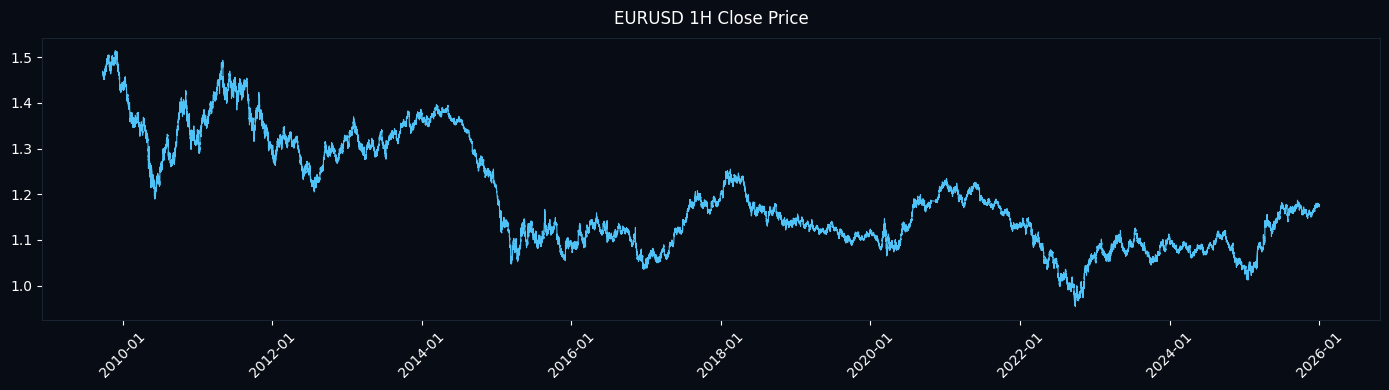

Price range: 0.95389 — 1.51419


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_check.index, df_check['close'], color='#4fc3f7', linewidth=0.8)
ax.set_facecolor('#080c14')
fig.patch.set_facecolor('#080c14')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#1a2332')
ax.set_title(f'{pair_to_check} {tf_to_check} Close Price', color='white', pad=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, color='white')
plt.tight_layout()
plt.show()

print(f'Price range: {df_check["close"].min():.5f} — {df_check["close"].max():.5f}')

In [13]:
# Full summary
print('Processed files summary:\n')
print(f'{"Pair":<10} {"TF":<6} {"Candles":<10} {"From":<14} {"To"}')
print('-' * 58)

for pair in PAIRS:
    for tf in ['5m', '15m', '1H', '4H', '1D', '1W']:
        path = PROCESSED_DIR / f'{pair}_{tf}.parquet'
        if path.exists():
            df = pd.read_parquet(path)
            if len(df) == 0:
                print(f'{pair:<10} {tf:<6} EMPTY')
            else:
                print(f'{pair:<10} {tf:<6} {len(df):<10} {str(df.index[0].date()):<14} {df.index[-1].date()}')
        else:
            print(f'{pair:<10} {tf:<6} MISSING')

Processed files summary:

Pair       TF     Candles    From           To
----------------------------------------------------------
EURUSD     5m     1177346    2009-09-25     2025-12-31
EURUSD     15m    392814     2009-09-25     2025-12-31
EURUSD     1H     98491      2009-09-25     2025-12-31
EURUSD     4H     25176      2009-09-25     2025-12-31
EURUSD     1D     4211       2009-09-25     2025-12-31
EURUSD     1W     EMPTY
GBPUSD     5m     1175270    2009-09-25     2025-12-31
GBPUSD     15m    392153     2009-09-25     2025-12-31
GBPUSD     1H     98339      2009-09-25     2025-12-31
GBPUSD     4H     25146      2009-09-25     2025-12-31
GBPUSD     1D     4211       2009-09-25     2025-12-31
GBPUSD     1W     EMPTY
USDJPY     5m     1169046    2009-09-28     2025-12-31
USDJPY     15m    390089     2009-09-28     2025-12-31
USDJPY     1H     97817      2009-09-28     2025-12-31
USDJPY     4H     25005      2009-09-28     2025-12-31
USDJPY     1D     4185       2009-09-28     2025-1